## The below is an Excersise focused on practicing the Code 

- Make a binary classification dataset with Scikit-Learn's make_moons() function.
- For consistency, the dataset should have 1000 samples and a random_state=42.
- Turn the data into PyTorch tensors. Split the data into training and test sets using train_test_split with 80% training and 20% testing.

In [26]:
import torch
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


In [27]:
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test  = torch.tensor(X_test,  dtype=torch.float32).to(device)

y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
y_test  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1).to(device)

- Build a model by subclassing nn.Module that incorporates non-linear activation functions and is capable of fitting the data you created in 1.
- Feel free to use any combination of PyTorch layers (linear and non-linear) you want.


In [30]:
# Create a non-linear model for make_moons dataset

class MoonModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Input layer (2 features → 32 hidden units)
        self.layer1 = nn.Linear(2, 32)
        
        # Hidden layer (32 → 32)
        self.layer2 = nn.Linear(32, 32)
        
        # Output layer (32 → 1 for binary classification)
        self.layer3 = nn.Linear(32, 1)
        
        # Non-linear activation
        self.relu = nn.ReLU()

    def forward(self, x):
        # Forward pass with non-linearity
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)   # Raw logits (no sigmoid here)
        return x

In [31]:
# Instantiate the model and move to device
model = MoonModel().to(device)

print(model)


MoonModel(
  (layer1): Linear(in_features=2, out_features=32, bias=True)
  (layer2): Linear(in_features=32, out_features=32, bias=True)
  (layer3): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)


Setup a binary classification compatible loss function and optimizer to use when training the model

In [33]:
# Binary classification loss (works with raw logits from the model)
loss_fn = nn.BCEWithLogitsLoss()

# Optimizer (updates model parameters)
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)

print("Loss function:", loss_fn)
print("Optimizer:", optimizer)

Loss function: BCEWithLogitsLoss()
Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


- Create a training and testing loop to fit the model you created in 2 to the data you created in 1.
- To measure model accuracy, you can create your own accuracy function or use the accuracy function in TorchMetrics.
- Train the model for long enough for it to reach over 96% accuracy.
- The training loop should output progress every 10 epochs of the model's training and test set loss and accuracy.

In [38]:
# Binary accuracy function
def binary_accuracy(y_true, y_logits):
    # Convert logits → probabilities
    y_probs = torch.sigmoid(y_logits)
    
    # Convert probabilities → predicted labels (0 or 1)
    y_pred = (y_probs >= 0.5).float()
    
    # Calculate accuracy
    correct = (y_pred == y_true).float().sum()
    acc = correct / len(y_true)
    
    return acc


In [ ]:
epochs = 1000  # Large enough to reach >96%


In [39]:
for epoch in range(epochs):
    
    # ======================
    # TRAINING
    # ======================
    model.train()
    
    # Forward pass
    train_logits = model(X_train)
    train_loss = loss_fn(train_logits, y_train)
    train_acc = binary_accuracy(y_train, train_logits)
    
    # Backpropagation
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()
    
    
    # ======================
    # TESTING
    # ======================
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_loss = loss_fn(test_logits, y_test)
        test_acc = binary_accuracy(y_test, test_logits)
    
    
    # ======================
    # PRINT PROGRESS
    # ======================
    if epoch % 10 == 0:
        print(f"Epoch {epoch}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
        print(f"Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc*100:.2f}%")
        print("-" * 40)


Epoch 0
Train Loss: 0.0753 | Train Acc: 98.00%
Test  Loss: 0.0577 | Test  Acc: 98.50%
----------------------------------------
Epoch 10
Train Loss: 0.0721 | Train Acc: 98.12%
Test  Loss: 0.0553 | Test  Acc: 99.00%
----------------------------------------
Epoch 20
Train Loss: 0.0690 | Train Acc: 98.12%
Test  Loss: 0.0530 | Test  Acc: 99.00%
----------------------------------------
Epoch 30
Train Loss: 0.0662 | Train Acc: 98.38%
Test  Loss: 0.0508 | Test  Acc: 99.00%
----------------------------------------
Epoch 40
Train Loss: 0.0635 | Train Acc: 98.50%
Test  Loss: 0.0487 | Test  Acc: 99.00%
----------------------------------------
Epoch 50
Train Loss: 0.0609 | Train Acc: 98.88%
Test  Loss: 0.0468 | Test  Acc: 99.00%
----------------------------------------
Epoch 60
Train Loss: 0.0585 | Train Acc: 98.88%
Test  Loss: 0.0449 | Test  Acc: 99.00%
----------------------------------------
Epoch 70
Train Loss: 0.0562 | Train Acc: 98.88%
Test  Loss: 0.0431 | Test  Acc: 99.00%
------------------

Make predictions with your trained model and plot them using the plot_decision_boundary() function created in this notebook.

In [42]:
import matplotlib.pyplot as plt
import numpy as np

def plot_decision_boundary(model, X, y):
    
    model.eval()
    
    # Move data to CPU (required for numpy & matplotlib)
    X = X.cpu()
    y = y.cpu()
    
    # Setup prediction boundaries
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )
    
    # Create feature grid
    X_to_pred = torch.from_numpy(
        np.column_stack((xx.ravel(), yy.ravel()))
    ).float()
    
    # Move grid to same device as model
    X_to_pred = X_to_pred.to(next(model.parameters()).device)
    
    # Make predictions
    with torch.inference_mode():
        logits = model(X_to_pred)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
    
    preds = preds.reshape(xx.shape).cpu()
    
    # Plot decision boundary
    plt.contourf(xx, yy, preds, alpha=0.5, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.title("Decision Boundary")
    plt.show()


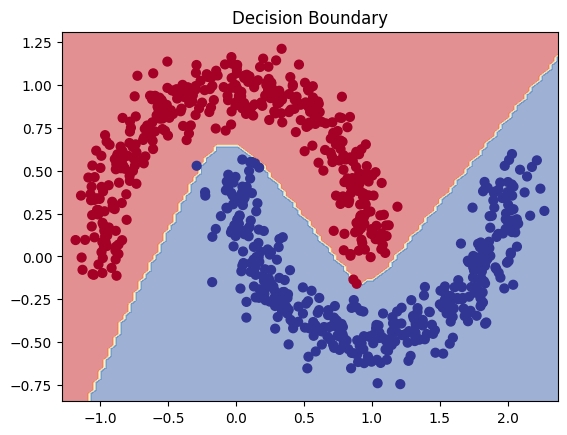

In [43]:
plot_decision_boundary(model, X_train, y_train.squeeze())
